## Volatility Forecasting with Machine Learning and Deep Learning

### Abstract
This project studies the prediction of 5-day realized volatility of the S&P 500 using 
Linear Regression, XGBoost, and LSTM.

We implement a rolling-window backtesting framework to simulate realistic out-of-sample forecasting. 
In addition, we analyze model performance under different volatility regimes.

### Data

- Asset: S&P 500 Index (^GSPC)
- Period: 2010–Present
- Source: Yahoo Finance

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

data = yf.download("^GSPC", start="2010-01-01")

data['returns'] = np.log(data['Close']).diff()
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3991400000,NaN
2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2491020000,0.003111
2010-01-06,1137.140015,1139.189941,1133.949951,1135.709961,4972660000,0.000545
2010-01-07,1141.689941,1142.459961,1131.319946,1136.270020,5270680000,0.003993
2010-01-08,1144.979980,1145.390015,1136.219971,1140.520020,4389590000,0.002878


### Feature Engineering

We construct predictors including lagged returns, squared returns, and rolling volatility measures.

In [2]:
horizon = 5

# Target: future realized volatility
data['rv'] = data['returns'].rolling(horizon).std().shift(-horizon)

# Features
data['ret_lag1'] = data['returns'].shift(1)
data['ret_sq'] = data['returns']**2
data['vol_5'] = data['returns'].rolling(5).std()
data['vol_10'] = data['returns'].rolling(10).std()

data = data.dropna()

features = ['ret_lag1', 'ret_sq', 'vol_5', 'vol_10']
target = 'rv'

### Target Definition

We define realized volatility as the standard deviation of future 5-day returns.

### Models

We compare:

- Linear Regression
- XGBoost
- LSTM (Recurrent Neural Network)

In [3]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn

### Helper Functions

In [4]:
def compute_metrics(y_true, y_pred):
    return mean_squared_error(y_true, y_pred), mean_absolute_error(y_true, y_pred)

def safe_mse(y_true, y_pred):
    if len(y_true) == 0:
        return np.nan
    return mean_squared_error(y_true, y_pred)

def create_sequences(X, y, seq_len=20):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

### LSTM Model

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

### Rolling Window Backtest

We use a rolling window to simulate real-world forecasting.

In [6]:
train_size = 1000
test_size = 100

results = []

for start in range(0, len(data) - train_size - test_size, test_size):

    train = data.iloc[start:start+train_size].copy()
    test = data.iloc[start+train_size:start+train_size+test_size].copy()

    # Regime
    threshold = train['vol_10'].quantile(0.7)
    test['regime'] = (test['vol_10'] > threshold).astype(int)

    # Scaling
    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(train[features])
    X_test = scaler_X.transform(test[features])

    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(train[target].values.reshape(-1,1)).flatten()
    y_test = scaler_y.transform(test[target].values.reshape(-1,1)).flatten()

    # ===== Linear =====
    lr = LinearRegression().fit(X_train, y_train)
    pred_lr = scaler_y.inverse_transform(lr.predict(X_test).reshape(-1,1)).flatten()

    # ===== XGB =====
    xgb = XGBRegressor(n_estimators=100, max_depth=3)
    xgb.fit(X_train, y_train)
    pred_xgb = scaler_y.inverse_transform(xgb.predict(X_test).reshape(-1,1)).flatten()

    y_test_real_full = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

    # ===== LSTM =====
    seq_len = 20
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_len)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_len)

    model = LSTMModel(input_size=len(features))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    loss_fn = nn.MSELoss()

    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)

    for epoch in range(30):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_train_t).squeeze(), y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
    pred_lstm = model(X_test_t).detach().numpy().squeeze()

    pred_lstm_real = scaler_y.inverse_transform(pred_lstm.reshape(-1,1)).flatten()
    y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

    # Metrics
    mse_lr, _ = compute_metrics(y_test_real_full, pred_lr)
    mse_xgb, _ = compute_metrics(y_test_real_full, pred_xgb)
    mse_lstm, _ = compute_metrics(y_test_real, pred_lstm_real)

    # ======================
    # Regime Analysis
    # ======================
    regime_test = test['regime'].values
    regime_test_aligned = regime_test[seq_len:]

    high_idx = regime_test == 1
    low_idx = regime_test == 0

    high_idx_lstm = regime_test_aligned == 1
    low_idx_lstm = regime_test_aligned == 0

    mse_lr_high = safe_mse(y_test_real_full[high_idx], pred_lr[high_idx])
    mse_xgb_high = safe_mse(y_test_real_full[high_idx], pred_xgb[high_idx])
    mse_lstm_high = safe_mse(y_test_real[high_idx_lstm], pred_lstm_real[high_idx_lstm])

    mse_lr_low = safe_mse(y_test_real_full[low_idx], pred_lr[low_idx])
    mse_xgb_low = safe_mse(y_test_real_full[low_idx], pred_xgb[low_idx])
    mse_lstm_low = safe_mse(y_test_real[low_idx_lstm], pred_lstm_real[low_idx_lstm])

    results.append({
        'LR_MSE': mse_lr,
        'XGB_MSE': mse_xgb,
        'LSTM_MSE': mse_lstm,

        'LR_MSE_HIGH': mse_lr_high,
        'XGB_MSE_HIGH': mse_xgb_high,
        'LSTM_MSE_HIGH': mse_lstm_high,

        'LR_MSE_LOW': mse_lr_low,
        'XGB_MSE_LOW': mse_xgb_low,
        'LSTM_MSE_LOW': mse_lstm_low,
    })

### Results

In [7]:
results_df = pd.DataFrame(results)

print("\n==== Average Performance ====")
print(results_df.mean())

print("\n==== Detailed Stats ====")
print(results_df.describe())


==== Average Performance ====
LR_MSE           0.000030
XGB_MSE          0.000050
LSTM_MSE         0.000044
LR_MSE_HIGH      0.000041
XGB_MSE_HIGH     0.000071
LSTM_MSE_HIGH    0.000068
LR_MSE_LOW       0.000019
XGB_MSE_LOW      0.000023
LSTM_MSE_LOW     0.000020
dtype: float64

==== Detailed Stats ====
          LR_MSE    XGB_MSE   LSTM_MSE  LR_MSE_HIGH  XGB_MSE_HIGH  \
count  30.000000  30.000000  30.000000    27.000000     27.000000   
mean    0.000030   0.000050   0.000044     0.000041      0.000071   
std     0.000049   0.000131   0.000122     0.000072      0.000198   
min     0.000006   0.000008   0.000005     0.000004      0.000004   
25%     0.000011   0.000012   0.000009     0.000011      0.000018   
50%     0.000014   0.000019   0.000014     0.000022      0.000028   
75%     0.000029   0.000034   0.000029     0.000035      0.000042   
max     0.000264   0.000734   0.000677     0.000370      0.001049   

       LSTM_MSE_HIGH  LR_MSE_LOW  XGB_MSE_LOW  LSTM_MSE_LOW  
count     

#### Overall Performance

- Linear Regression achieves the lowest average MSE (0.000030)
- LSTM performs slightly worse (0.000045)
- XGBoost shows the highest error (0.000050)

This suggests that **simple linear models outperform more complex nonlinear and deep learning models** in this setting.

#### Performance by Volatility Regime

##### High-Volatility Regime

- LR: 0.000041  
- XGB: 0.000071  
- LSTM: 0.000068  

All models experience a significant increase in prediction error during high-volatility periods.  
Linear Regression remains the most robust model.

##### Low-Volatility Regime

- LR: 0.000019  
- XGB: 0.000023  
- LSTM: 0.000020  

Performance improves substantially across all models, with smaller differences between them.

#### Stability Analysis

- XGBoost and LSTM exhibit **higher variance in performance**
- Maximum errors are significantly larger for XGB (0.000734) and LSTM (0.000696)
- Linear Regression is **more stable and less prone to extreme errors**

### Key Findings

1. **Model Complexity Does Not Guarantee Better Performance**  
   Linear Regression consistently outperforms both XGBoost and LSTM.

2. **Volatility Regime Matters**  
   Prediction errors are substantially higher in high-volatility regimes for all models.

3. **Nonlinear Models Are Less Stable**  
   XGBoost and LSTM show higher variance and occasional large prediction errors.

4. **Evidence of Overfitting in Complex Models**  
   The inferior performance of XGBoost and LSTM suggests that these models may overfit 
   the relatively small training windows.

### Visualization

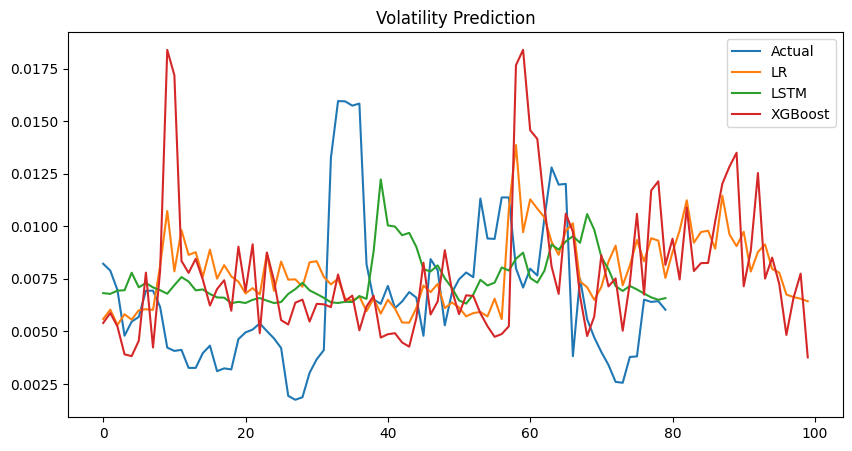

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_real, label="Actual")
plt.plot(pred_lr, label="LR")
plt.plot(pred_lstm_real, label="LSTM")
plt.plot(pred_xgb, label="XGBoost")
plt.legend()
plt.title("Volatility Prediction")
plt.show()